# Swiss Roll Generator Benchmark

This notebook compares several pretrained generators from this repository on the same 2D swiss-roll target distribution.

We use point-cloud metrics that make sense in 2D, such as sliced Wasserstein and energy distance, plus side-by-side scatter plots.

## Crash course: comparing distributions

When you compare samples from a real distribution and a generated distribution, there are two common goals:

- **distance / score**: how far apart are they?
- **hypothesis test**: can we reject the idea that they came from the same distribution?

A few useful families:

### Wasserstein distance
Think of this as the minimum amount of work needed to move one distribution into the other. It is geometric and often very intuitive.

### Sliced Wasserstein
Project both distributions onto many random 1D lines, compute a 1D Wasserstein distance on each projection, then average.

$$
\mathrm{SW}(P,Q) \approx \frac{1}{K} \sum_{k=1}^K W_1\big((u_k^\top)_\# P, (u_k^\top)_\# Q\big),
$$

where each $u_k$ is a random unit direction and $(u_k^\top)_\# P$ means "project $P$ onto the line spanned by $u_k$."

It is popular because it is much cheaper than full high-dimensional Wasserstein, while still respecting geometry better than coordinate-wise comparisons.

### MMD
Maximum Mean Discrepancy compares kernel mean embeddings of the two sample sets. It is a very standard two-sample test and works well when you want a formal statistical comparison.

### Energy distance
A simple pairwise-distance based metric / test. It is often a strong baseline for low-dimensional sample comparison.

### FID
FID compares distributions in a *feature space* from a pretrained Inception network. It is mainly an image metric, not a generic metric for arbitrary toy data.

For our 2D experiments here, **sliced Wasserstein, energy distance, or MMD** are usually more appropriate than FID.

### Rule of thumb
- If you care about transport geometry: use Wasserstein / sliced Wasserstein.
- If you care about a two-sample test: use MMD or an energy-style test.
- If you are evaluating images: FID is convenient, but only because the feature extractor is meaningful for vision.

So for this notebook, a good evaluation metric would be sliced Wasserstein or energy distance rather than FID.

In [ ]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path
import seaborn as sns

import common
importlib.reload(common)
from common import (
    load_swiss_roll, TinyMLP, MeanFlowMLP,
    cosine_beta_schedule, extract,
    load_or_train,
    generate_samples_euler, generate_samples_ode,
    generate_samples_ddpm, generate_samples_mean_flow as generate_samples_meanflow,
)

%matplotlib inline
sns.set_style("darkgrid")

torch.Size([10000, 2])


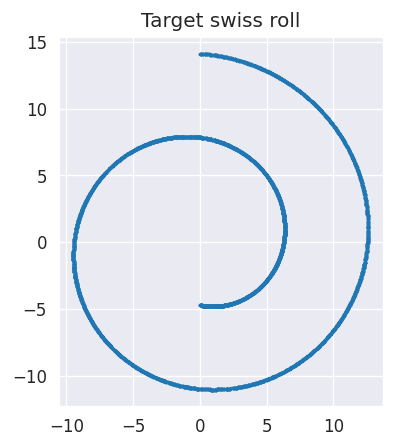

In [2]:
train_set, swiss_roll = load_swiss_roll(n_samples=10000, noise=0)
print(train_set.shape)
plt.figure(figsize=(4, 4), dpi=120)
plt.axes().set_aspect('equal')
plt.scatter(swiss_roll[:, 0], swiss_roll[:, 1], s=1)
plt.title('Target swiss roll')
plt.show()

In [ ]:
def _never_train(*args, **kwargs):
    raise RuntimeError("Checkpoint missing: this benchmark notebook expects pretrained weights.")


def load_from_ckpt(model, name, ckpt_dir=Path("checkpoints")):
    _ = load_or_train(
        model=model,
        name=name,
        train_step=_never_train,
        data=train_set,
        niter=1,
        lr=1e-3,
        ckpt_dir=ckpt_dir,
        load=True,
        save=False,
    )
    model.eval()
    return model


def sliced_wasserstein_2d(real, fake, n_dirs=256):
    real = np.asarray(real)
    fake = np.asarray(fake)
    directions = np.random.randn(n_dirs, 2)
    directions = directions / np.linalg.norm(directions, axis=1, keepdims=True)
    values = []
    for u in directions:
        pr = np.sort(real @ u)
        pf = np.sort(fake @ u)
        values.append(np.mean(np.abs(pr - pf)))
    return float(np.mean(values))


def energy_distance(real, fake):
    real = np.asarray(real)
    fake = np.asarray(fake)
    rr = np.linalg.norm(real[:, None, :] - real[None, :, :], axis=-1)
    ff = np.linalg.norm(fake[:, None, :] - fake[None, :, :], axis=-1)
    rf = np.linalg.norm(real[:, None, :] - fake[None, :, :], axis=-1)
    return float(2 * rf.mean() - rr.mean() - ff.mean())


T_DDPM = 1000
_betas = cosine_beta_schedule(T_DDPM)
_alphas_cumprod = torch.cumprod(1. - _betas, dim=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_fm_v = load_from_ckpt(TinyMLP(2, 32, time_dim=0, x_prediction=False).to(device), 'flow_matching_vpred')
model_fm_x = load_from_ckpt(TinyMLP(2, 32, time_dim=0, x_prediction=True).to(device), 'flow_matching_xpred')
model_ddpm = load_from_ckpt(TinyMLP(2, 32, time_dim=32, x_prediction=False).to(device), 'flow_matching_ddpm')
model_mf = load_from_ckpt(MeanFlowMLP(2, 128, time_dim=0, n_residual=7).to(device), 'mean_flow')
model_imf = load_from_ckpt(MeanFlowMLP(2, 128, time_dim=0, n_residual=7).to(device), 'improved_mean_flow')

real = train_set.cpu().numpy()

NameError: name 'load_state' is not defined

In [ ]:
# One representative sampling setting per generator
samples = {
    'FM v-pred (Euler 1000)': generate_samples_euler(model_fm_v, n_samples=10000, n_steps=1000).numpy(),
    'FM x-pred (Euler 1000)': generate_samples_euler(model_fm_x, n_samples=10000, n_steps=1000).numpy(),
    'DDPM (DDIM 50)': generate_samples_ddpm(model_ddpm, _betas, _alphas_cumprod, 10000, n_steps=50).numpy(),
    'Mean Flow (1 step)': generate_samples_meanflow(model_mf, n_samples=10000, n_steps=1).numpy(),
    'Mean Flow (5 steps)': generate_samples_meanflow(model_mf, n_samples=10000, n_steps=5).numpy(),
    'Improved MF (1 step)': generate_samples_meanflow(model_imf, n_samples=10000, n_steps=1).numpy(),
}

rows = []
for name, fake in samples.items():
    rows.append((name, sliced_wasserstein_2d(real, fake), energy_distance(real, fake)))

rows = sorted(rows, key=lambda x: x[1])
for name, swd, ed in rows:
    print(f'{name:24s}  SWD={swd:.4f}  Energy={ed:.4f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=120)
axes = axes.ravel()
axes[0].scatter(real[:, 0], real[:, 1], s=1, alpha=0.25, c='black')
axes[0].set_title('Real swiss roll')
for ax, (name, fake) in zip(axes[1:], samples.items()):
    ax.scatter(fake[:, 0], fake[:, 1], s=1, alpha=0.25)
    ax.set_title(name)
for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

NameError: name '_betas' is not defined

In [ ]:
# Compare Mean Flow step counts directly
step_counts = [1, 2, 5, 15]
mf_benchmark = []
for n_steps in step_counts:
    fake = generate_samples_meanflow(model_mf, n_samples=10000, n_steps=n_steps).numpy()
    mf_benchmark.append((n_steps, sliced_wasserstein_2d(real, fake), energy_distance(real, fake)))

for n_steps, swd, ed in mf_benchmark:
    print(f'Mean Flow {n_steps:2d} steps  SWD={swd:.4f}  Energy={ed:.4f}')

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=130)
ax.plot([x[0] for x in mf_benchmark], [x[1] for x in mf_benchmark], marker='o', label='Sliced Wasserstein')
ax.plot([x[0] for x in mf_benchmark], [x[2] for x in mf_benchmark], marker='o', label='Energy distance')
ax.set_xlabel('Mean Flow steps')
ax.set_title('Mean Flow quality vs step count')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'T_DDPM' is not defined